# 다층 퍼셉트론으로 클래스 모델 구성 및 하이퍼파라미터 최적화

- 목차
1. 라이브러리 import
2. 데이터 준비
    - 학습/검증/테스트 데이터 분리
    - 데이터 표준화
    - Tensor 형태로 데이터 변환
3. 미니배치 준비
4. 모델 준비
5. 학습 및 평가 함수 (+Early Stopping)
6. Optuna 활용하여 하이퍼파라미터 최적화
7. 최적의 파라미터로 재학습
8. 시각화

1. 라이브러리 import

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터, 데이터 분리, 스케일링, 지표
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

# 텐서 조작 및 pytorch 기본, 레이어 구성, 최적화함수, 배치 데이터셋 구성
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 기타 라이브러리
import optuna # 최적화
import warnings # 경고 메시지 제어
warnings.filterwarnings('ignore') # 경고 메시지 무시
from tqdm import tqdm # 프로그래스바

plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False

c:\Workspace\DL\dl_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2. 데이터 준비

In [2]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
print(X.shape, y.shape)

(569, 30) (569,)


In [3]:
# Test 데이터 분리 (최종 성능 평가용)
X_trainval,X_test,y_trainval,y_test = train_test_split(
    X, y,
    test_size = 0.2,  # 80:20
    random_state=42,
    stratify=y        # 클래스 비율을 유지하면서 분할
)

In [4]:
# Train/Valid 데이터 분리 (하이퍼파라미터 최적화용)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,
    random_state=42,
    stratify=y_trainval
)

print(X_train.shape, X_val.shape, X_test.shape)

(341, 30) (114, 30) (114, 30)


In [5]:
# 입력 데이터 표준화 (평균 0, 표준편차 1로 x데이터 스케일 조정)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(X_train.shape, X_val.shape,X_test.shape)

(341, 30) (114, 30) (114, 30)


In [6]:
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).reshape(-1, 1)
X_val_t   = torch.FloatTensor(X_val)
y_val_t   = torch.FloatTensor(y_val).reshape(-1, 1)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test).reshape(-1, 1)

print(X_train_t.size(),y_train_t.size(),X_val_t.size(),y_val_t.size(),X_test_t.size(),y_test_t.size())

torch.Size([341, 30]) torch.Size([341, 1]) torch.Size([114, 30]) torch.Size([114, 1]) torch.Size([114, 30]) torch.Size([114, 1])


3. 미니배치 준비

In [7]:
# 미니배치 : 학습/검증/테스트용 DataLoader를 생성하는 함수
def make_loaders(batch_size=64):
    train_loader = DataLoader(
        TensorDataset(X_train_t,y_train_t),# 학습용 입력(x)와 정답(y)를 묶어 전달
        batch_size= batch_size,            # 미니 배치 크기
        shuffle=True                       # 학습용 데이터는 섞어서 일반화 성능 향상
    )
    val_loader = DataLoader(
        TensorDataset(X_val_t,y_val_t),
        batch_size= batch_size,
        shuffle=False                      # 검증용 데이터는 순서 고정
    )
    test_loader = DataLoader(
        TensorDataset(X_test_t,y_test_t),
        batch_size= batch_size,
        shuffle=False                      # 검증용 데이터는 순서 고정
    )

    return train_loader,val_loader,test_loader # 3종류의 DataLoader 반환

미니배치용 데이터로더 만들때 학습 데이터는 shuffle,  
검증, 테스트 데이터는 고정된 순서로 로딩시키는 것이 기본 원칙이다.

4. 모델 준비

In [8]:
# 다층 퍼셉트론 이진분류 모델 (출력은 logit 1개)
class MLP(nn.Module):

    def __init__(self,input_dim, hidden_dim1=64, hidden_dim2=32, dropout_p=0.0):
        super().__init__()  # nn.Module 초기화
        self.fc1 = nn.Linear(input_dim, hidden_dim1)  # 입력 -> 첫번째 은닉층
        self.fc2 = nn.Linear(hidden_dim1,hidden_dim2) # 첫 번째 은닉층 -> 두번째 은닉층
        self.fc_out = nn.Linear(hidden_dim2,1)        # 출력층 : 두 번째 은닉층 -> logit값 1개 출력

        self.act = nn.ReLU() # 활성화함수
        self.dropout = nn.Dropout(dropout_p) if dropout_p > 0 else nn.Identity() # Dropout 사용 또는 없을시 통과

    def forward(self, x):
        x = self.act(self.fc1(x)) # 첫 번째 은닉층 + ReLU
        x = self.dropout(x)       # Dropout 적용
        x = self.act(self.fc2(x)) # 두 번째 은닉층 + ReLU
        x = self.dropout(x)       # Dropout 적용
        x = self.fc_out(x)        # 출력층 (logits)

        return x # (batch_size, 1) 형태로 출력

5. 학습 및 평가 함수

In [9]:
criterion = nn.BCEWithLogitsLoss()

# 학습 함수
def train_one_epoch(model, loader, optimizer):
    model.train()  # 학습 모드로 전환
    losses = []    # 배치별 loss를 저장할 리스트

    for xb, yb in loader: # 미니배치 단위로 (입력, 정답) 반복
        logits = model(xb) # 순전파 : 모델 출력 (logit) 계산

        loss = criterion(logits, yb) # 예측(logit)과 정답(0/1)으로 BCE 손실 계산

        optimizer.zero_grad() # 이전 step의 기울기 초기화
        loss.backward()       # 역전파 : 현재 loss 기준으로 기울기 계산
        optimizer.step()      # 계산된 기울기로 파라미터(가중치/편향) 업데이트

        losses.append(loss.item()) # 파이썬 숫자 형태로 loss 값 저장

    return float(np.mean(losses))  # 1 epoch 동안 평균 train loss 반환

In [10]:
# 평가 함수
@torch.no_grad()
def evaluate(model,loader):
    model.eval()    # 평가 모드로 전환 (dropout 비활성화, batchNorm은 고정 통계 사용)
    losses = []     # 배치별 loss
    y_true_all = [] # 실제 정답
    y_prob_all = [] # 예측 확률

    # 미니배치 단위로 반복
    for xb, yb in loader:
        logits = model(xb)  # 순전파 : 모델 출력 (logit) 계산
        loss = criterion(logits, yb) # 검증/테스트 loss 계산
        prob = torch.sigmoid(logits) # logit -> 확률 0~1 변환 (시각화/평가지표)

        losses.append(loss.item())           # loss 기록
        y_true_all.append(yb.cpu().numpy())  # 정답을 numpy형태로 변환
        y_prob_all.append(prob.cpu().numpy())# 예측 확률도 numpy형태로 변환

    y_true = np.vstack(y_true_all).ravel()
    y_prob = np.vstack(y_prob_all).ravel()
    y_pred = (y_prob > 0.5).astype(int) # 임계값 0.5를 기준으로 클래스 0/1 결정

    acc = accuracy_score(y_true, y_pred) # 정확도 계산
    auc = roc_auc_score(y_true, y_prob)  # ROC-AUC 계산 (확률 기반)

    return float(np.mean(losses)), acc, auc, y_true, y_prob #평균 Loss, acc, auc, 정답/확률 반환

```
np.vstack(y_true_all).ravel()
y_true_all = [
    array([[1],[0],[1],[0], ...]), # 첫번째 배치
    array([[1],[0],[1],[0], ...])  # 두번째 배치
]

np.vstack() : 세로로 붙이기 (배치들을 하나로 이어 붙여줌)

array([
    [1],
    [0],
    [1],
    [0],
    ...
])

ravel() : 배열들을 1차원으로 평탄화 (flatten)
(N, 1) -> (N, )
array([1,0,1,0,0,1, ...])

np.vstack(y_true_all).reshape(-1) 해도 동일한 효과
np.vstack(y_true_all).flatten() 해도 동일한 효과

이렇게 사용하는 이유 : accuracy_score나 roc_auc_score 등 각종 평가지표들이 1차원 배열을 매개값으로 요구함.
```

In [11]:
# Ealry Stopping : 검증시 손실이 더 이상 개선되지 않으면 학습을 조기에 중단하는 클래스
class EarlyStopping():
    def __init__(self, patience=20, min_delta=0.0):
        self.patience = patience    # 성능 개선이 없어도 허용할 epoch
        self.min_delta = min_delta  # 개선으로 인정할 최소 손실 감소량
        self.best = float("inf")    # 최소 검증 손실
        self.counter = 0            # 연속으로 개선되지 않은 epoch 수
        self.stop = False           # 학습 중단 여부 플래그

    def step(self, val_loss):
        # 최대 손실에서 최소 손실 감소량만큼 뺀 것보다 더 손실이 적어지면 (개선되면)
        if val_loss < self.best - self.min_delta:
            self.best = val_loss  # 해당 loss 기록
            self.counter = 0      # 카운터 초기화
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True  # 학습 중단 신호

In [12]:
# 모델 학습, 검증 손실 기록, Early Stopping으로 과적합 방지하는 함수
def fit(model, train_loader, val_loader, lr=1e-3, n_epoch=200, weight_decay=0.0):
    optimizer = optim.Adam(
        model.parameters(),
        lr = lr,
        weight_decay= weight_decay # L2 정규화(과적합 완화)
    )

    hist = {"train_loss": [],"val_loss": [],"val_acc": [],"val_auc": []}
    best_val = np.inf # 최고 val_loss 기록
    best_state = None # 최고 성능 모델 가중치

    early = EarlyStopping(patience=20) # val_loss 기준 20번 개선 없으면 조기종료

    for epoch in range(1, n_epoch + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer) # 1 epoch 학습 후 train_loss 반환
        va_loss,va_acc,va_auc,_,_ = evaluate(model, val_loader) # 검증 손실 등 지표

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["val_acc"].append(va_acc)
        hist["val_auc"].append(va_auc)

        if va_loss < best_val: # 더 성능이 개선되면
            best_val = va_loss # best_val 업데이트
            # 현재 best 모델의 가중치 스냅샷 저장
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        early.step(va_loss) # early stopping 상태 갱신
        if early.stop: # patiench만큼 개선 없을 경우 True
            print(f"Epochs {epoch}에서 종료")
            break
    if best_state is not None:
        model.load_state_dict(best_state) # 저장해둔 best 가중치 모델 복원

    return hist # 시각화용 지표 변환

6. Optuna 활용하여 하이퍼파라미터 최적화

In [13]:
def objective(trial):
    hidden_dim1 = trial.suggest_categorical("hidden_dim1", [32,64,128,256]) # 은닉 1층 노드
    hidden_dim2 = trial.suggest_categorical("hidden_dim2", [16,32,64,128]) # 은닉 2층 노드
    dropout_p = trial.suggest_float("dropout_p", 0.0,0.5) # dropout 비율 (과적합 방지용)
    lr = trial.suggest_float("lr",1e-4,1e-2, log=True)    # 학습률
    weight_decay = trial.suggest_float("weight_decay",1e-6,1e-3, log=True) # L2 규제 (과적합 방지용)

    batch_size = trial.suggest_categorical("batch_size",[32,64,128]) # 배칭 크기
    train_loader, val_loader, _ = make_loaders(batch_size=batch_size)

    model = MLP(
        input_dim=X_train.shape[-1],
        hidden_dim1=hidden_dim1,
        hidden_dim2=hidden_dim2,
        dropout_p=dropout_p
    )

    hist = fit(
        model,train_loader,val_loader, 
        lr=lr,
        n_epoch=15,
        weight_decay=weight_decay
    )
    best_val_auc = float(np.max(hist["val_auc"]))
    return best_val_auc # Optuna가 최대화할 목적 함수 값

study = optuna.create_study(direction="maximize") # Optuna Study 객체
study.optimize(objective, n_trials=20) # objective 함수 20회 실행하며 탐색

print(f"옵투나 최고 성능 조합 : {study.best_params}") # 최적의 하이퍼파라미터 조합
print(f"옵투나 최고 성능의 val_auc : {study.best_value}") # 해당 파라미터에서의 최고 성능 AUC

[I 2026-07-28 10:26:06,903] A new study created in memory with name: no-name-9d5503c8-307a-4ad7-86e4-8a3c26cc4ff2
[I 2026-07-28 10:26:08,599] Trial 0 finished with value: 0.9842777595807403 and parameters: {'hidden_dim1': 32, 'hidden_dim2': 16, 'dropout_p': 0.20601270007563566, 'lr': 0.00040184465572379405, 'weight_decay': 1.150615787058451e-05, 'batch_size': 128}. Best is trial 0 with value: 0.9842777595807403.
[I 2026-07-28 10:26:08,866] Trial 1 finished with value: 0.9980347199475925 and parameters: {'hidden_dim1': 32, 'hidden_dim2': 32, 'dropout_p': 0.0679911081124982, 'lr': 0.009690406324071988, 'weight_decay': 4.340136358827621e-06, 'batch_size': 32}. Best is trial 1 with value: 0.9980347199475925.
[I 2026-07-28 10:26:09,098] Trial 2 finished with value: 0.9983622666229938 and parameters: {'hidden_dim1': 256, 'hidden_dim2': 16, 'dropout_p': 0.42507050408498565, 'lr': 0.0031909236448256872, 'weight_decay': 0.00024894291456805924, 'batch_size': 64}. Best is trial 2 with value: 0.99

옵투나 최고 성능 조합 : {'hidden_dim1': 64, 'hidden_dim2': 128, 'dropout_p': 0.11404775296872427, 'lr': 0.009450541006741378, 'weight_decay': 0.0009647420555978164, 'batch_size': 32}
옵투나 최고 성능의 val_auc : 0.998689813298395


7. 최적의 하이퍼파라미터로 재학습

In [14]:
best = study.best_params

train_loader, val_loader, test_loader = make_loaders(batch_size=best['batch_size'])

best_model = MLP(
    input_dim = X_train.shape[-1],
    hidden_dim1=best['hidden_dim1'],
    hidden_dim2=best['hidden_dim2'],
    dropout_p=best['dropout_p']
)

history = fit(
    best_model,
    train_loader, val_loader,
    lr = best['lr'],
    n_epoch = 1000,
    weight_decay=best['weight_decay']
)

test_loss, test_acc, test_auc, y_true, y_prob = evaluate(best_model, test_loader)

print(f"Test 기준 정확도 : {test_acc:.4f}, 최저 loss : {test_loss:.4f}, auc : {test_auc:.4f}")

Epochs 34에서 종료
Test 기준 정확도 : 0.9561, 최저 loss : 0.1605, auc : 0.9917


8. 시각화

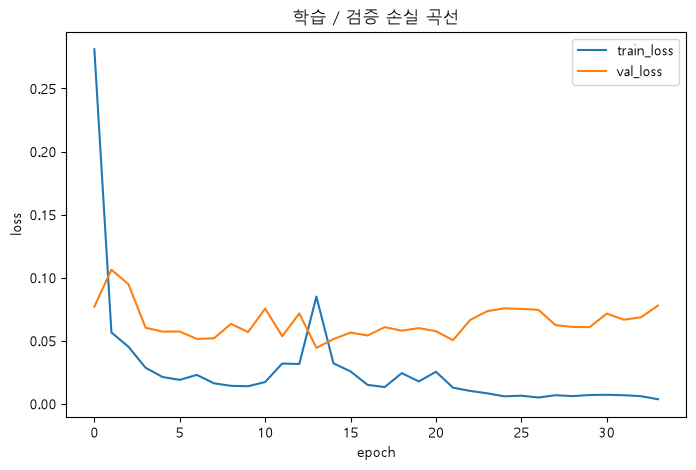

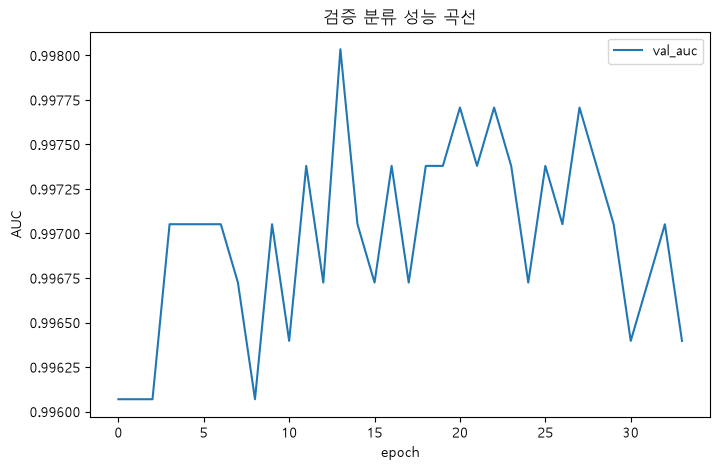

In [15]:
# Train / Valid Loss 학습 곡선, Val AUC

plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("학습 / 검증 손실 곡선")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["val_auc"], label="val_auc")
plt.xlabel("epoch")
plt.ylabel("AUC")
plt.title("검증 분류 성능 곡선")
plt.legend()
plt.show()


손실 곡선 : 학습 손실은 줄어드는데 검증 손실은 줄어들지 않으면 과적합 신호로 본다.

AUC 곡선 : 모델의 전반적인 분류 능력이 어떻게 변하는지 확인  
AUC가 꾸준히 상승하면 클래스 간 구분 능력이 향상되고 있음.

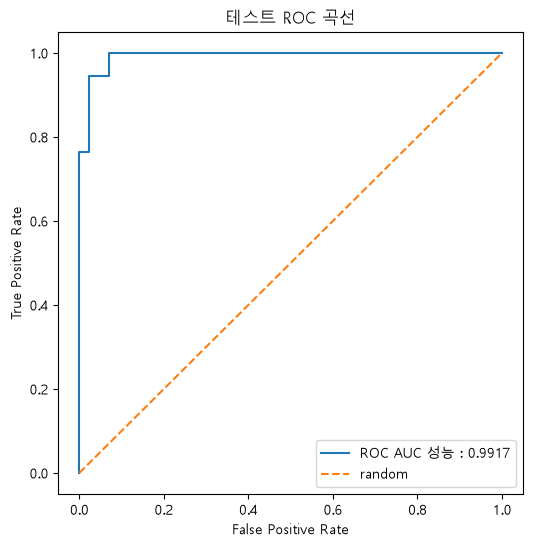

In [ ]:
fpr, tpr, thr = roc_curve(y_true, y_prob) # 실제값과 예측확률로 ROC 곡선 좌표 계산 (FP 거짓양성, TP 참양성, 임계)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC AUC 성능 : {test_auc:.4f}") # ROC 곡선 (AUC 값 표시)
plt.plot([0,1],[0,1], linestyle="--", label="random")      # 무작위 분류 기준선 (대각선)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("테스트 ROC 곡선")
plt.legend()
plt.show()

ROC 곡선은 모델이 양성과 음성을 얼마나 잘 구분하는지 확인할 수 있는 지표있다.  
여기서 AUC는 ROC곡선 아래 면적으로, 무작위로 하나의 양성과 음성을 선택했을 때 모델이 올바르게 순서를 매길 확률이다.  

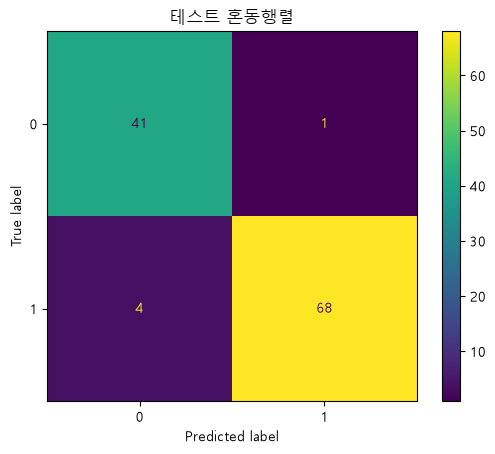

In [ ]:
y_pred = (y_prob > 0.5).astype(int) # 모델의 예측 (0/1)
cm = confusion_matrix(y_true, y_pred) # 실제값과 예측값 비교 혼동행렬 계산
disp = ConfusionMatrixDisplay(confusion_matrix=cm) # 혼동행렬 시각화 객체
disp.plot()
plt.title("테스트 혼동행렬")
plt.show()

혼동행렬은 각 클래스 별로 얼마나 맞추고 틀렷는지를 직접적으로 볼 수 있다.

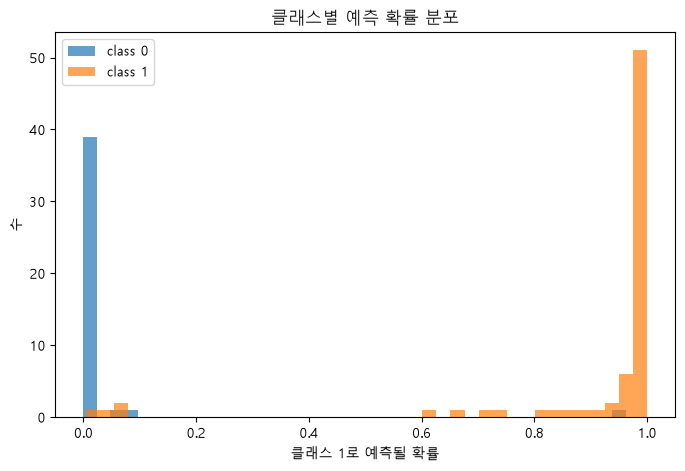

In [19]:
# 클래스별 예측 확률 분포
plt.figure(figsize = (8,5))

plt.hist(
    y_prob[y_true == 0],
    bins = 40,
    alpha = 0.7,
    label = "class 0"
)
plt.hist(
    y_prob[y_true == 1],
    bins = 40,
    alpha = 0.7,
    label = "class 1"
)
plt.xlabel("클래스 1로 예측될 확률")
plt.ylabel("수")
plt.title("클래스별 예측 확률 분포")
plt.legend()
plt.show()

두 클래스가 겹치는 부분은 약간 존재하긴 하지만 그렇게 크지 않음.  
분류 경계가 명확한 편이고, 모델의 확신이 높은편임.

혼자서 공부하면서 적용해볼만한 사항
1. 은닉층 증축 설계 & 하이퍼파라미터 최적화
2. 최적화 함수 변경 (Adam -> AdamW, NAdam, RAdam)
3. 스케일러 변경 (StandardScaler -> MinMaxScaler, RobustScaler)

4. 데이터 불균형시 SMOTE
5. 과적합 발생시
- Dropout / BatchNorm
- Scheduler : lr를 점진적으로 조절 (ReduceLROnPlateau)
- Early Stopping
- K-Fold Cross Validation